# 07 Contamination Sensitivity Analysis

这一份 notebook 用来检验：

> 当 `Isolation Forest` 的 `contamination` 从 0.01 到 0.10 变化时，主异常窗口 `12115~12135` 是否依然稳定存在。

注意：
- 这里不是为了证明某个 `contamination` 是唯一正确值
- 这里重点验证的是：主异常窗口是否对参数变化具有稳健性
- 由于没有真实标签，`contamination=0.05` 只能作为 baseline 假设，而不是“真值”


## 0. 导入库

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1800)


## 1. 读取并清洗数据

这里仍然直接从原始数据出发，沿用已经确认过的清洗逻辑。

In [2]:
df = pd.read_csv('../data/PWR Abnormality Dataset.csv')

# 清洗 Flow2
df['Flow2'] = df['Flow2'].astype(str).str.strip().str.replace(',', '.', regex=False)
df['Flow2'] = pd.to_numeric(df['Flow2'], errors='coerce')

df_clean = df.copy()
df_model = df.drop(columns=['Readings'])

print('原始数据形状：', df.shape)
print('建模数据形状：', df_model.shape)
print('Flow2 缺失值数量：', df['Flow2'].isna().sum())

原始数据形状： (12267, 17)
建模数据形状： (12267, 16)
Flow2 缺失值数量： 0


## 2. 标准化

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

print('标准化后数据形状：', X_scaled.shape)

标准化后数据形状： (12267, 16)


## 3. 设定异常窗口与污染率列表

前面已经通过 baseline 分析定位出主异常窗口大致在 `12115~12135`。

In [4]:
window_start = 12115
window_end = 12135

contamination_list = [0.01, 0.03, 0.05, 0.08, 0.10]

results = []
top10_dict = {}
score_dict = {}

## 4. 不同 contamination 下逐个重跑 Isolation Forest

这里记录四类信息：
- 总异常样本数
- 异常窗口中被判成异常的样本数和比例
- top10 最异常样本中，有多少落在主异常窗口内
- 异常窗口的平均异常分数


In [7]:
for c in contamination_list:
    model = IsolationForest(contamination=c, random_state=42)
    pred = model.fit_predict(X_scaled)
    scores = model.decision_function(X_scaled)

    temp_df = df_clean.copy()
    temp_df['anomaly_label'] = pred
    temp_df['anomaly_score'] = scores

    total_anomaly_count = (temp_df['anomaly_label'] == -1).sum()

    window_df = temp_df[(temp_df['Readings'] >= window_start) & (temp_df['Readings'] <= window_end)].copy()
    window_anomaly_count = (window_df['anomaly_label'] == -1).sum()
    window_size = len(window_df)
    window_anomaly_ratio = window_anomaly_count / window_size

    top10_df = temp_df.sort_values(by='anomaly_score', ascending=True).head(10)
    top10_hit_count = ((top10_df['Readings'] >= window_start) & (top10_df['Readings'] <= window_end)).sum()

    window_score_mean = window_df['anomaly_score'].mean()
    global_score_mean = temp_df['anomaly_score'].mean()

    results.append({
        'contamination': c,
        'total_anomaly_count': total_anomaly_count,
        'window_size': window_size,
        'window_anomaly_count': window_anomaly_count,
        'window_anomaly_ratio': window_anomaly_ratio,
        'top10_hit_count': top10_hit_count,
        'window_score_mean': window_score_mean,
        'global_score_mean': global_score_mean
    })

    top10_dict[c] = top10_df[['Readings', 'Temperature', 'Pressure', 'Flow1', 'Flow2', 'anomaly_label', 'anomaly_score']]
    score_dict[c] = temp_df[['Readings', 'anomaly_score']]

## 5. 汇总结果表

In [8]:
summary_df = pd.DataFrame(results).sort_values(by='contamination')

print('不同 contamination 下的稳健性汇总：')
display(summary_df)

summary_df.to_csv('../outputs/tables/contamination_sensitivity_summary.csv', index=False)
print('已保存到 ../outputs/tables/contamination_sensitivity_summary.csv')

不同 contamination 下的稳健性汇总：


,contamination,total_anomaly_count,window_size,window_anomaly_count,window_anomaly_ratio,top10_hit_count,window_score_mean,global_score_mean
0,0.01,123,21,21,1.0,10,-0.054762,0.078849
1,0.03,368,21,21,1.0,10,-0.079994,0.053617
2,0.05,614,21,21,1.0,10,-0.089357,0.044255
3,0.08,982,21,21,1.0,10,-0.097343,0.036269
4,0.10,1227,21,21,1.0,10,-0.100975,0.032636


已保存到 ../outputs/tables/contamination_sensitivity_summary.csv


## 6. 分别查看不同 contamination 下的 top10 最异常样本

这里重点看：
- top10 是否集中在 `12115~12135`
- 不同 contamination 下，top10 是否基本稳定

In [9]:
for c in contamination_list:
    print(f'\n===== contamination = {c} =====')
    print('top10 最异常样本：')
    display(top10_dict[c])


===== contamination = 0.01 =====
top10 最异常样本：


,Readings,Temperature,Pressure,Flow1,Flow2,anomaly_label,anomaly_score
12127,12128,287.8287,16.57636,4461.264172,14388.58200,-1,-0.070169
12124,12125,288.0672,16.58000,4484.036774,13972.37300,-1,-0.066199
12129,12130,287.5891,16.58719,4427.619761,13927.95706,-1,-0.063113
12118,12119,287.9721,16.47419,4480.147273,14956.03029,-1,-0.061138
12119,12120,287.9612,16.57160,4425.837560,14831.58653,-1,-0.059545
12121,12122,287.8750,16.57655,4409.037954,14942.36383,-1,-0.057912
12128,12129,287.6377,16.57587,4354.601835,13553.30673,-1,-0.057827
12123,12124,287.9897,16.57410,4369.390259,14016.13886,-1,-0.056816
12131,12132,287.6651,16.00017,4412.651254,13402.11830,-1,-0.056452
12116,12117,288.0049,16.57498,4322.022756,14935.33727,-1,-0.056327



===== contamination = 0.03 =====
top10 最异常样本：


,Readings,Temperature,Pressure,Flow1,Flow2,anomaly_label,anomaly_score
12127,12128,287.8287,16.57636,4461.264172,14388.58200,-1,-0.095400
12124,12125,288.0672,16.58000,4484.036774,13972.37300,-1,-0.091430
12129,12130,287.5891,16.58719,4427.619761,13927.95706,-1,-0.088345
12118,12119,287.9721,16.47419,4480.147273,14956.03029,-1,-0.086370
12119,12120,287.9612,16.57160,4425.837560,14831.58653,-1,-0.084777
12121,12122,287.8750,16.57655,4409.037954,14942.36383,-1,-0.083143
12128,12129,287.6377,16.57587,4354.601835,13553.30673,-1,-0.083059
12123,12124,287.9897,16.57410,4369.390259,14016.13886,-1,-0.082048
12131,12132,287.6651,16.00017,4412.651254,13402.11830,-1,-0.081683
12116,12117,288.0049,16.57498,4322.022756,14935.33727,-1,-0.081558



===== contamination = 0.05 =====
top10 最异常样本：


,Readings,Temperature,Pressure,Flow1,Flow2,anomaly_label,anomaly_score
12127,12128,287.8287,16.57636,4461.264172,14388.58200,-1,-0.104763
12124,12125,288.0672,16.58000,4484.036774,13972.37300,-1,-0.100793
12129,12130,287.5891,16.58719,4427.619761,13927.95706,-1,-0.097707
12118,12119,287.9721,16.47419,4480.147273,14956.03029,-1,-0.095733
12119,12120,287.9612,16.57160,4425.837560,14831.58653,-1,-0.094140
12121,12122,287.8750,16.57655,4409.037954,14942.36383,-1,-0.092506
12128,12129,287.6377,16.57587,4354.601835,13553.30673,-1,-0.092421
12123,12124,287.9897,16.57410,4369.390259,14016.13886,-1,-0.091411
12131,12132,287.6651,16.00017,4412.651254,13402.11830,-1,-0.091046
12116,12117,288.0049,16.57498,4322.022756,14935.33727,-1,-0.090921



===== contamination = 0.08 =====
top10 最异常样本：


,Readings,Temperature,Pressure,Flow1,Flow2,anomaly_label,anomaly_score
12127,12128,287.8287,16.57636,4461.264172,14388.58200,-1,-0.112749
12124,12125,288.0672,16.58000,4484.036774,13972.37300,-1,-0.108779
12129,12130,287.5891,16.58719,4427.619761,13927.95706,-1,-0.105693
12118,12119,287.9721,16.47419,4480.147273,14956.03029,-1,-0.103719
12119,12120,287.9612,16.57160,4425.837560,14831.58653,-1,-0.102126
12121,12122,287.8750,16.57655,4409.037954,14942.36383,-1,-0.100492
12128,12129,287.6377,16.57587,4354.601835,13553.30673,-1,-0.100407
12123,12124,287.9897,16.57410,4369.390259,14016.13886,-1,-0.099397
12131,12132,287.6651,16.00017,4412.651254,13402.11830,-1,-0.099032
12116,12117,288.0049,16.57498,4322.022756,14935.33727,-1,-0.098907



===== contamination = 0.1 =====
top10 最异常样本：


,Readings,Temperature,Pressure,Flow1,Flow2,anomaly_label,anomaly_score
12127,12128,287.8287,16.57636,4461.264172,14388.58200,-1,-0.116382
12124,12125,288.0672,16.58000,4484.036774,13972.37300,-1,-0.112412
12129,12130,287.5891,16.58719,4427.619761,13927.95706,-1,-0.109326
12118,12119,287.9721,16.47419,4480.147273,14956.03029,-1,-0.107351
12119,12120,287.9612,16.57160,4425.837560,14831.58653,-1,-0.105758
12121,12122,287.8750,16.57655,4409.037954,14942.36383,-1,-0.104124
12128,12129,287.6377,16.57587,4354.601835,13553.30673,-1,-0.104040
12123,12124,287.9897,16.57410,4369.390259,14016.13886,-1,-0.103029
12131,12132,287.6651,16.00017,4412.651254,13402.11830,-1,-0.102664
12116,12117,288.0049,16.57498,4322.022756,14935.33727,-1,-0.102539


## 7. 图 1：异常窗口命中比例 vs contamination

这张图看的是：异常窗口中的样本，有多少比例会被模型判成异常。

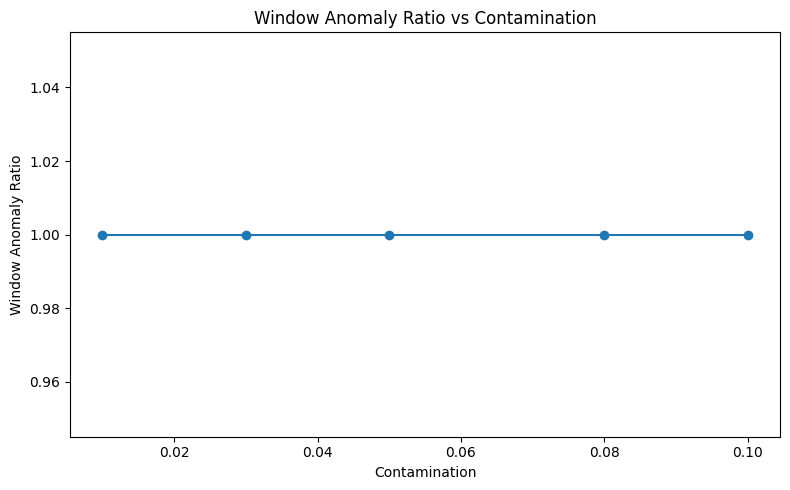

图片已保存到 ../outputs/figures/window_anomaly_ratio_vs_contamination.png


In [10]:
plt.figure(figsize=(8, 5))
plt.plot(summary_df['contamination'], summary_df['window_anomaly_ratio'], marker='o')
plt.xlabel('Contamination')
plt.ylabel('Window Anomaly Ratio')
plt.title('Window Anomaly Ratio vs Contamination')
plt.tight_layout()
plt.savefig('../outputs/figures/window_anomaly_ratio_vs_contamination.png', dpi=300)
plt.show()

print('图片已保存到 ../outputs/figures/window_anomaly_ratio_vs_contamination.png')

## 8. 图 2：top10 窗口命中数 vs contamination

这张图看的是：top10 最异常样本中，有多少个落在主异常窗口内。

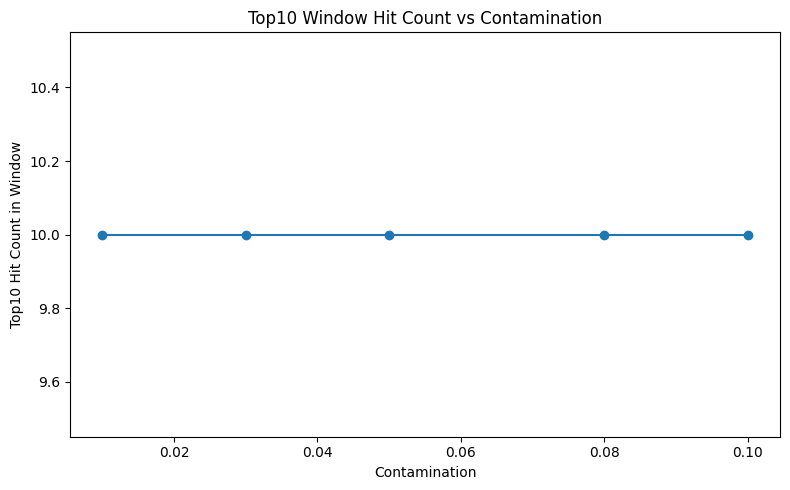

图片已保存到 ../outputs/figures/top10_hit_count_vs_contamination.png


In [11]:
plt.figure(figsize=(8, 5))
plt.plot(summary_df['contamination'], summary_df['top10_hit_count'], marker='o')
plt.xlabel('Contamination')
plt.ylabel('Top10 Hit Count in Window')
plt.title('Top10 Window Hit Count vs Contamination')
plt.tight_layout()
plt.savefig('../outputs/figures/top10_hit_count_vs_contamination.png', dpi=300)
plt.show()

print('图片已保存到 ../outputs/figures/top10_hit_count_vs_contamination.png')

## 9. 图 3：不同 contamination 下的局部异常分数曲线

重点看：
- `12115~12135` 这段低谷是否持续存在
- 不同 contamination 下，这段低谷的相对位置是否稳定

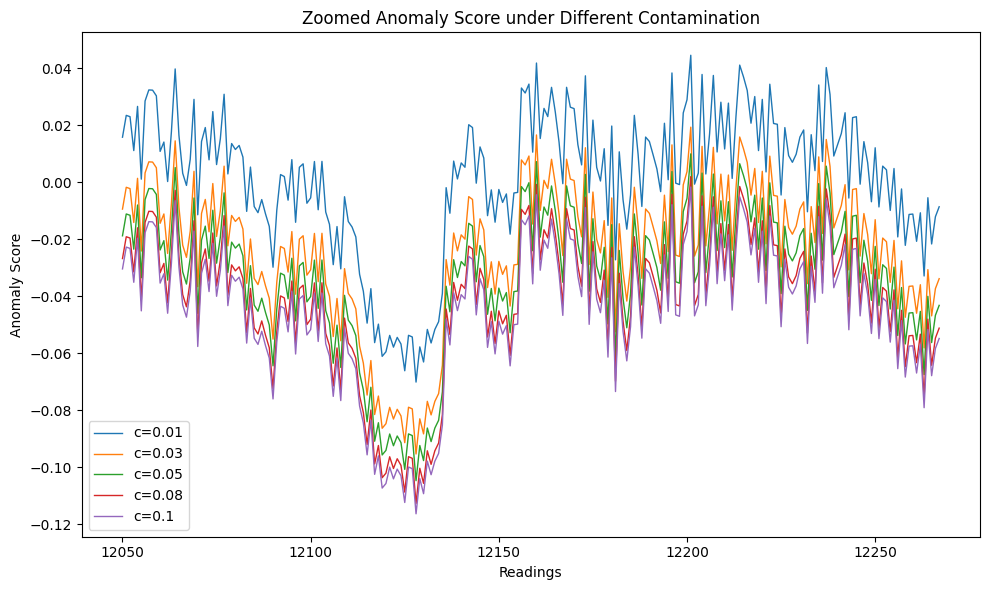

图片已保存到 ../outputs/figures/anomaly_score_zoom_multi_contamination.png


In [12]:
plt.figure(figsize=(10, 6))

for c in contamination_list:
    temp_score_df = score_dict[c]
    zoom_score_df = temp_score_df[(temp_score_df['Readings'] >= 12050) & (temp_score_df['Readings'] <= 12267)]
    plt.plot(zoom_score_df['Readings'], zoom_score_df['anomaly_score'], label=f'c={c}', linewidth=1)

plt.xlabel('Readings')
plt.ylabel('Anomaly Score')
plt.title('Zoomed Anomaly Score under Different Contamination')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/anomaly_score_zoom_multi_contamination.png', dpi=300)
plt.show()

print('图片已保存到 ../outputs/figures/anomaly_score_zoom_multi_contamination.png')

## 10. 阶段性结论

这里建议重点关注：
1. `top10_hit_count` 是否始终较高
2. `window_anomaly_ratio` 是否始终较高
3. 不同 contamination 下，主异常窗口低谷是否持续存在

如果这些条件都成立，那么可以认为：
> 主异常窗口 `12115~12135` 对 contamination 参数变化具有较好的稳健性，`contamination=0.05` 作为 baseline 设置是合理的。